Transfer Learning with ResNet18

In [5]:

import os
from pathlib import Path 

import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets , transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns




In [2]:

# Paths and config
DATA_ROOT = Path(r"C:\Users\HP\Desktop\pneumonia_ai_v1\data\chest_xray")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
#  TRANSFORMS (Copy from baseline)
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
# DATASETS & LOADERS (Copy from baseline)

train_ds = datasets.ImageFolder(root=DATA_ROOT / "train", transform=train_transform)
val_ds   = datasets.ImageFolder(root=DATA_ROOT / "val",   transform=val_test_transform)
test_ds  = datasets.ImageFolder(root=DATA_ROOT / "test",  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,num_workers=NUM_WORKERS)

class_names = train_ds.classes
print("Classes:", class_names)
print(f"Train: {len(train_ds)} images")
print(f"Val: {len(val_ds)} images")
print(f"Test: {len(test_ds)} images")

Classes: ['NORMAL', 'PNEUMONIA']
Train: 4174 images
Val: 1058 images
Test: 624 images


In [7]:
# CLASS WEIGHTS (Copy with 2.0 denominator - BEST)
labels_np = np.array(train_ds.targets)
class_counts = np.bincount(labels_np)  # [count_normal, count_pneumonia]
print("Train class counts:", class_counts)

total = class_counts.sum()
class_weights = total / (2.0 * class_counts)  # 2.0 is BEST from experiments
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights (2.0 denominator):", class_weights_tensor)
print(f"Normal weight: {class_weights[0]:.3f}, Pneumonia weight: {class_weights[1]:.3f}")

Train class counts: [1073 3101]
Class weights (2.0 denominator): tensor([1.9450, 0.6730])
Normal weight: 1.945, Pneumonia weight: 0.673


NEW - Load Pre-trained ResNet18

In [8]:
import torchvision.models as models

print("loading pre-trained ResNet18..")

# 1. load model with ImageNet weights
resnet_model =models.resnet18(pretrained=True)

# 2. freeze all layers initially ( do not train them)
for param in resnet_model.parameters():
    param.requires_grad=False
print("all layers frozen (ImageNet knowledge preserved)")

# 3.replace final layer for our 2-class problem
num_features =resnet_model.fc.in_features  # Get input size of final layer
resnet_model.fc = nn.Linear(num_features,2) # Change to 2 outputs
print(f"Final layer replaced: {num_features} features → 2 classes")

# 4. move to device
resnet_model =resnet_model.to(device)

# 5. show model summary
print("\nResNet18 Model Summary:")
print(resnet_model)
print(f"\nTotal parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet_model.parameters() if p.requires_grad):,}")


loading pre-trained ResNet18..


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


all layers frozen (ImageNet knowledge preserved)
Final layer replaced: 512 features → 2 classes

ResNet18 Model Summary:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (

Loss Function & Optimizer

In [9]:

# Loss function (SAME as baseline)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer - ONLY train the final layer (fc) initially
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=1e-3)  # Only fc layer!

print("Optimizer setup:")
print(f"  Learning rate: 1e-3")
print(f"  Training ONLY final layer parameters")
print(f"  Class weights applied in loss function")

Optimizer setup:
  Learning rate: 1e-3
  Training ONLY final layer parameters
  Class weights applied in loss function


Training Functions

In [10]:
# TRAINING FUNCTIONS (Copy from baseline)

def train_one_epoch(model,loader,optimizer,criterion, device):
    model.train()
    running_loss =0.0
    correct=0
    total=0

    for images , labels in loader :
        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()
        outputs =model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss +=loss.item()* images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

Training Loop

In [11]:
num_epochs = 10  
best_val_loss = float("inf")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"\n{'='*60}")
print("STARTING TRANSFER LEARNING TRAINING")
print(f"Model: ResNet18 (pretrained)")
print(f"Training only final layer")
print(f"Epochs: {num_epochs}")
print(f"{'='*60}\n")

# Create directory for saving models
os.makedirs("artifacts/models", exist_ok=True)

for epoch in range(num_epochs):
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(resnet_model, train_loader, optimizer, criterion, device)
    
    # Evaluate on validation set
    val_loss, val_acc = evaluate(resnet_model, val_loader, criterion, device)
    
    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    # Print progress
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet_model.state_dict(), "artifacts/models/resnet18_best.pth")
        print(f"  → Saved new best model (val_loss: {val_loss:.4f})")

print(f"\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved to: artifacts/models/resnet18_best.pth")


STARTING TRANSFER LEARNING TRAINING
Model: ResNet18 (pretrained)
Training only final layer
Epochs: 10

Epoch  1/10 | Train Loss: 0.3223 | Train Acc: 0.8723 | Val Loss: 0.2534 | Val Acc: 0.8970
  → Saved new best model (val_loss: 0.2534)
Epoch  2/10 | Train Loss: 0.1978 | Train Acc: 0.9245 | Val Loss: 0.1902 | Val Acc: 0.9282
  → Saved new best model (val_loss: 0.1902)
Epoch  3/10 | Train Loss: 0.1830 | Train Acc: 0.9284 | Val Loss: 0.2172 | Val Acc: 0.9130
Epoch  4/10 | Train Loss: 0.1704 | Train Acc: 0.9305 | Val Loss: 0.1308 | Val Acc: 0.9471
  → Saved new best model (val_loss: 0.1308)
Epoch  5/10 | Train Loss: 0.1697 | Train Acc: 0.9356 | Val Loss: 0.1750 | Val Acc: 0.9367
Epoch  6/10 | Train Loss: 0.1632 | Train Acc: 0.9379 | Val Loss: 0.1242 | Val Acc: 0.9527
  → Saved new best model (val_loss: 0.1242)
Epoch  7/10 | Train Loss: 0.1524 | Train Acc: 0.9396 | Val Loss: 0.1622 | Val Acc: 0.9367
Epoch  8/10 | Train Loss: 0.1413 | Train Acc: 0.9468 | Val Loss: 0.1466 | Val Acc: 0.9423


In [12]:
# TEST THE BEST MODEL
print("\n" + "="*60)
print("TESTING RESNET18 ON UNSEEN DATA")
print("="*60)

# 1. Load the best saved model
best_resnet = models.resnet18(pretrained=False)  # Don't load ImageNet weights
num_features = best_resnet.fc.in_features
best_resnet.fc = nn.Linear(num_features, 2)  # Same architecture
best_resnet.load_state_dict(torch.load("artifacts/models/resnet18_best.pth", map_location=device))
best_resnet = best_resnet.to(device)
best_resnet.eval()
print("✓ Best model loaded successfully")

# 2. Evaluate on test set
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = best_resnet(images)
        _, preds = outputs.max(1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Calculate metrics
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
normal_recall = cm[0,0] / cm[0,:].sum()
pneumonia_recall = cm[1,1] / cm[1,:].sum()

print(f"\nKey Metrics:")
print(f"Test Accuracy: {accuracy:.2%}")
print(f"Normal Recall: {normal_recall:.2%}")
print(f"Pneumonia Recall: {pneumonia_recall:.2%}")


TESTING RESNET18 ON UNSEEN DATA


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Best model loaded successfully

Confusion Matrix:
[[157  77]
 [ 10 380]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.67      0.78       234
   PNEUMONIA       0.83      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624


Key Metrics:
Test Accuracy: 86.06%
Normal Recall: 67.09%
Pneumonia Recall: 97.44%


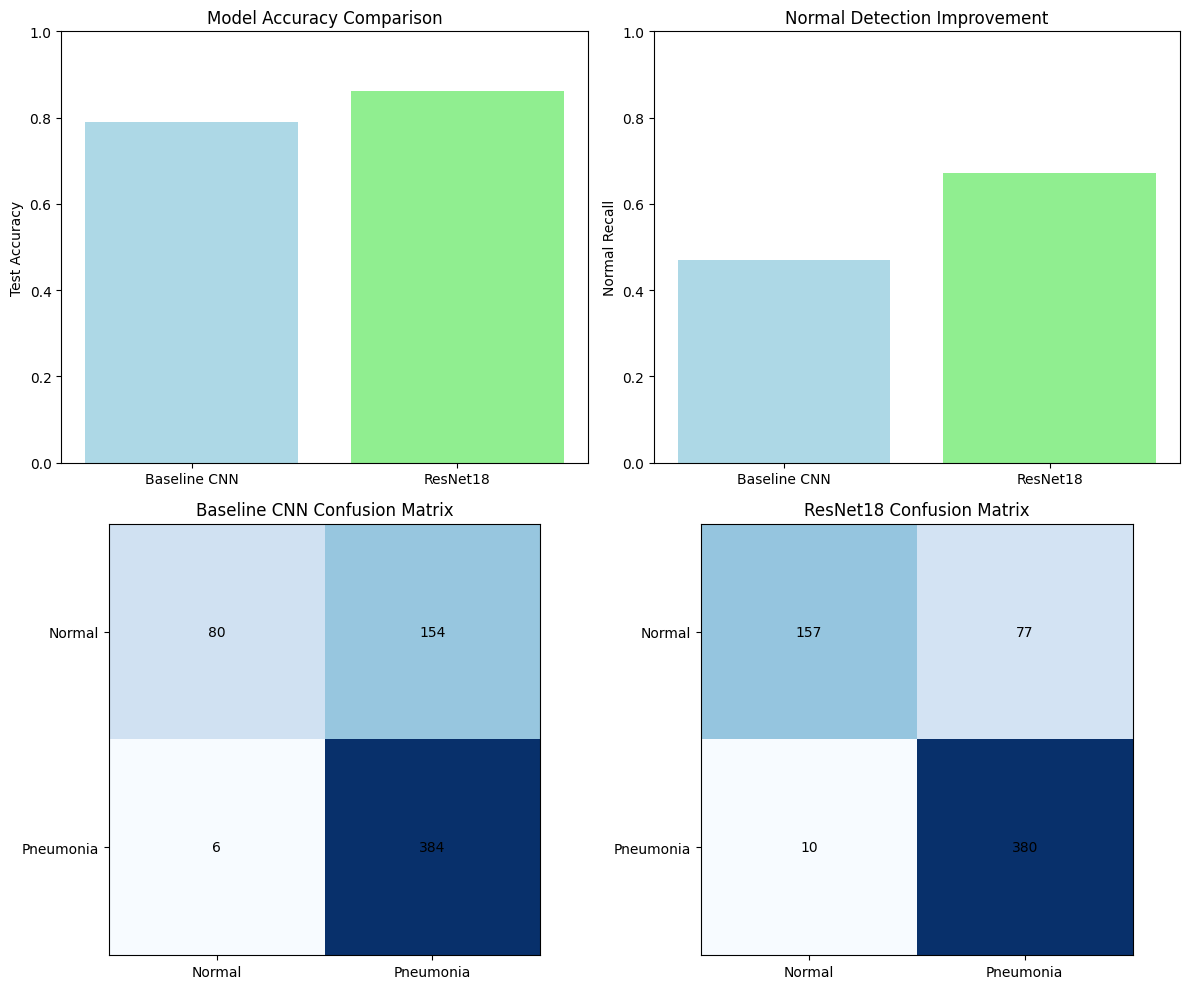

In [13]:
# COMPARISON VISUALIZATION
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Accuracy Comparison
axes[0,0].bar(['Baseline CNN', 'ResNet18'], [0.79, 0.861], color=['lightblue', 'lightgreen'])
axes[0,0].set_ylabel('Test Accuracy')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylim(0, 1)

# 2. Normal Recall Comparison
axes[0,1].bar(['Baseline CNN', 'ResNet18'], [0.47, 0.671], color=['lightblue', 'lightgreen'])
axes[0,1].set_ylabel('Normal Recall')
axes[0,1].set_title('Normal Detection Improvement')
axes[0,1].set_ylim(0, 1)

# 3. Confusion Matrix Comparison
cm1 = np.array([[80, 154], [6, 384]])  # Baseline
cm2 = np.array([[157, 77], [10, 380]])  # ResNet18

axes[1,0].imshow(cm1, cmap='Blues')
axes[1,0].set_title('Baseline CNN Confusion Matrix')
axes[1,0].set_xticks([0, 1])
axes[1,0].set_yticks([0, 1])
axes[1,0].set_xticklabels(['Normal', 'Pneumonia'])
axes[1,0].set_yticklabels(['Normal', 'Pneumonia'])
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, cm1[i, j], ha='center', va='center', color='black')

axes[1,1].imshow(cm2, cmap='Blues')
axes[1,1].set_title('ResNet18 Confusion Matrix')
axes[1,1].set_xticks([0, 1])
axes[1,1].set_yticks([0, 1])
axes[1,1].set_xticklabels(['Normal', 'Pneumonia'])
axes[1,1].set_yticklabels(['Normal', 'Pneumonia'])
for i in range(2):
    for j in range(2):
        axes[1,1].text(j, i, cm2[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()